<a href="https://colab.research.google.com/github/Agtna/DataMining/blob/main/datamining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import json
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score

%matplotlib inline
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("trending.csv", encoding="utf-8")
print("Jumlah baris & kolom:", df.shape)
df.head()

Jumlah baris & kolom: (172347, 27)


,video_id,publish_time,channel_id,title,description,thumbnail_url,thumbnail_width,thumbnail_height,channel_name,tags,...,caption,license_status,allowed_region,blocked_region,view,like,dislike,favorite,comment,trending_time
0,NaN,2021-02-05T09:00:34Z,UCEf_Bc-KVd7onSeifS3py9g,aespa 에스파 'Forever (약속)' MV,"aespa's new single ""Forever"" is out!\nListen a...",NaN,NaN,NaN,SMTOWN,NaN,...,True,True,NaN,NaN,7806846.0,857902.0,24078.0,0,94961.0,2021-02-07 05:46:51.832614+00:00
1,NaN,2021-02-04T15:54:08Z,UCYEa4_MC7OFjcWrO6SO-u8g,[FULL] Siapa di Balik Kudeta AHY? | Dua Sisi t...,"Jakarta, https://www.tvonenews.com - Ketua umu...",NaN,NaN,NaN,Indonesia Lawyers Club,"['tvone', 'tv one', 'tvonenews', 'indonesia la...",...,False,True,NaN,NaN,885038.0,6765.0,1263.0,0,6365.0,2021-02-07 05:46:51.832649+00:00
2,NaN,2021-02-06T03:00:22Z,UCu12RxQjRQyh79YBYvEDkOg,CABRIOLET CHALLENGE: TANTANGAN MENGGODA (7/12),Road Party Season 2: Cabriolet Challenge\n\nEp...,NaN,NaN,NaN,Motomobi,"['MotoMobi', 'Mobil', 'motor', 'review', 'indo...",...,False,True,NaN,NaN,889708.0,47895.0,532.0,0,8785.0,2021-02-07 05:46:51.832664+00:00
3,NaN,2021-02-05T20:26:08Z,UCCuzDCoI3EUOo_nhCj4noSw,With Windah Basudara & Hans,Join this channel to get access to perks:\nhtt...,NaN,NaN,NaN,yb,NaN,...,False,True,NaN,NaN,1006854.0,91973.0,3967.0,0,12957.0,2021-02-07 05:46:51.832678+00:00
4,NaN,2021-02-03T23:14:54Z,UC14UlmYlSNiQCBe9Eookf_A,🤯 LATE COMEBACK DRAMA! | HIGHLIGHTS | Granada ...,"With just two minutes to play, Barça looked to...",NaN,NaN,NaN,FC Barcelona,"['FC Barcelona', 'برشلونة،', 'Fútbol', 'FUTBOL...",...,False,True,NaN,NaN,6275035.0,218131.0,4289.0,0,12799.0,2021-02-07 05:46:51.832730+00:00


In [5]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172347 entries, 0 to 172346
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   video_id           119225 non-null  object 
 1   publish_time       172347 non-null  object 
 2   channel_id         172347 non-null  object 
 3   title              172347 non-null  object 
 4   description        165692 non-null  object 
 5   thumbnail_url      119225 non-null  object 
 6   thumbnail_width    119225 non-null  float64
 7   thumbnail_height   119225 non-null  float64
 8   channel_name       172347 non-null  object 
 9   tags               147148 non-null  object 
 10  category_id        172347 non-null  int64  
 11  live_status        172347 non-null  object 
 12  local_title        172347 non-null  object 
 13  local_description  165692 non-null  object 
 14  duration           172347 non-null  object 
 15  dimension          172347 non-null  object 
 16  de

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,119225,13339,hLz4xOo7MGQ,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publish_time,172347,23935,2022-04-08T10:30:11Z,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_id,172347,3257,UC1Gmqqs_Myzl2KHIeqfUC9A,1234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,172347,24664,Top Lagu Pop Indonesia Terbaru 2021 Hits Pilih...,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,165692,21830,Social Media:\nhttps://www.youtube.com/jessica...,770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thumbnail_url,119225,13339,https://i.ytimg.com/vi/hLz4xOo7MGQ/hqdefault.jpg,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thumbnail_width,119225.0,NaN,NaN,NaN,480.0,0.0,480.0,480.0,480.0,480.0,480.0
thumbnail_height,119225.0,NaN,NaN,NaN,360.0,0.0,360.0,360.0,360.0,360.0,360.0
channel_name,172347,3366,Nihongo Mantappu,1234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,147148,15291,"['JESSICA JANE', 'JESIKA JANE', '24 JAM JESSIC...",936,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Missing values per kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna(subset=['view', 'like'])

Missing values per kolom:
video_id              53122
publish_time              0
channel_id                0
title                     0
description            6655
thumbnail_url         53122
thumbnail_width       53122
thumbnail_height      53122
channel_name              0
tags                  25199
category_id               0
live_status               0
local_title               0
local_description      6655
duration                  0
dimension                 0
definition                0
caption                   0
license_status            0
allowed_region       166544
blocked_region       165715
view                     10
like                   1321
dislike              118717
favorite                  0
comment                 483
trending_time             0
dtype: int64

Jumlah baris duplikat: 0


In [7]:
print("Missing values per kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna(subset=['view', 'like'])

Missing values per kolom:
video_id              52493
publish_time              0
channel_id                0
title                     0
description            6542
thumbnail_url         52493
thumbnail_width       52493
thumbnail_height      52493
channel_name              0
tags                  24907
category_id               0
live_status               0
local_title               0
local_description      6542
duration                  0
dimension                 0
definition                0
caption                   0
license_status            0
allowed_region       165273
blocked_region       164458
view                      0
like                      0
dislike              117396
favorite                  0
comment                 437
trending_time             0
dtype: int64

Jumlah baris duplikat: 0


In [8]:
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['trending_time'] = pd.to_datetime(df['trending_time'], errors='coerce')

df['days_to_trend'] = (df['trending_time'] - df['publish_time']).dt.days
df['days_to_trend'] = df['days_to_trend'].clip(lower=0)

In [10]:
# Kalau di dataset ada file semacam ID_category_id.json, upload juga lalu jalankan ini:
try:
    with open("category.json", "r") as f:
        category_data = json.load(f)
    category_map = {int(item['id']): item['snippet']['title'] for item in category_data['items']}
    df['category_name'] = df['category_id'].map(category_map)
except FileNotFoundError:
    print("File JSON kategori tidak ditemukan, pakai category_id saja")
    df['category_name'] = df['category_id'].astype(str)

In [11]:
df['engagement_rate'] = (df['like'] + df['dislike'] + df['comment']) / (df['view'] + 1)
df['like_ratio'] = df['like'] / (df['like'] + df['dislike'] + 1)
df['tags_count'] = df['tags'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else len(str(x).split('|')))

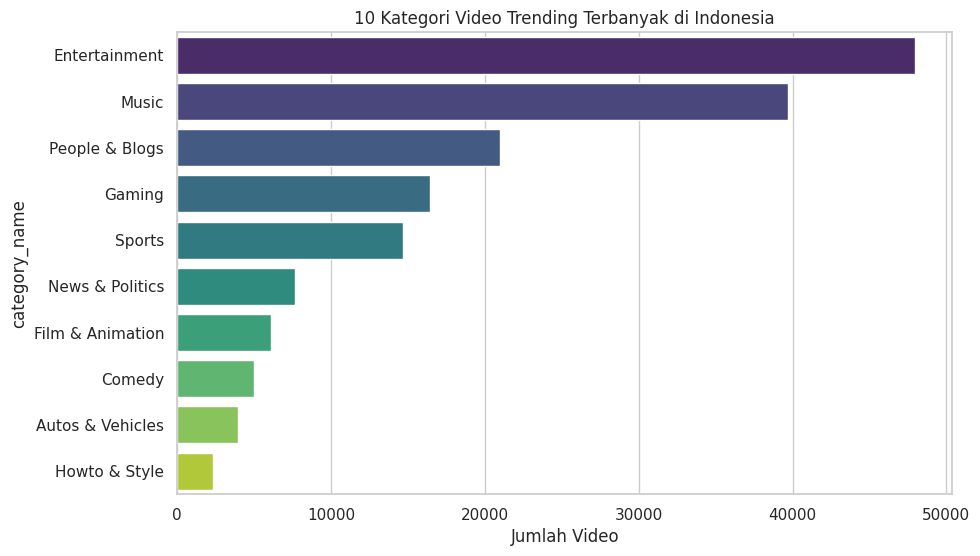

In [12]:
plt.figure(figsize=(10,6))
top_categories = df['category_name'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("10 Kategori Video Trending Terbanyak di Indonesia")
plt.xlabel("Jumlah Video")
plt.show()

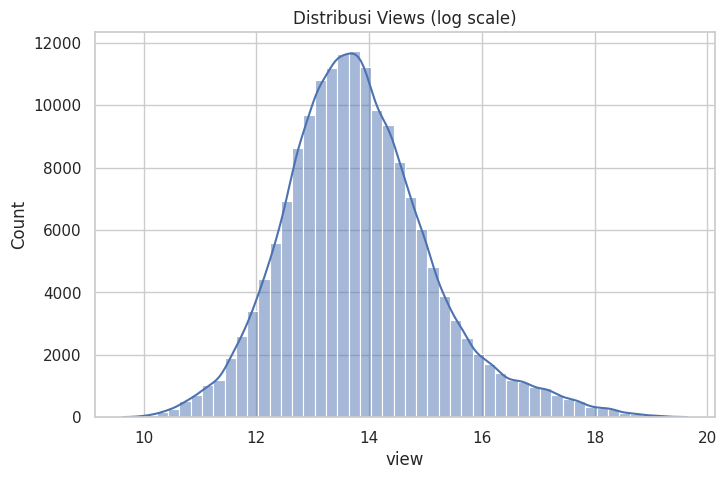

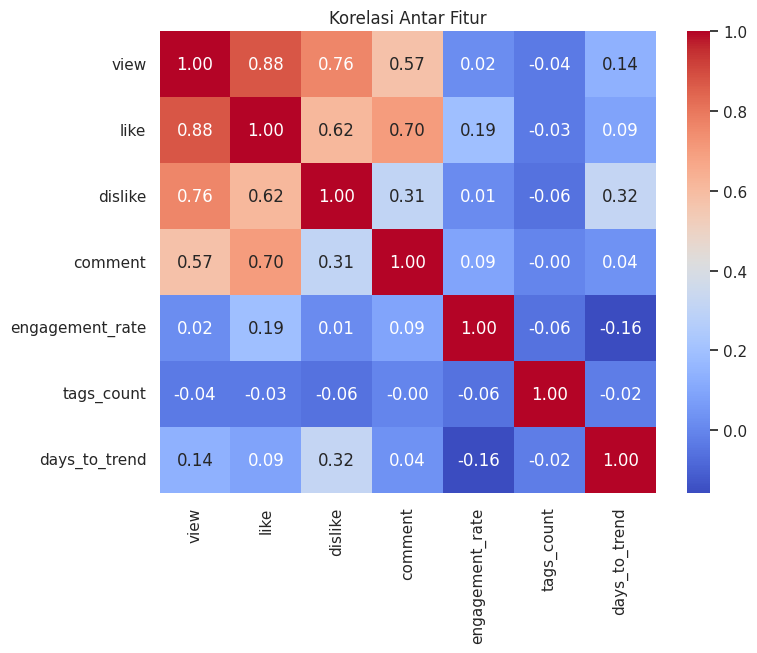

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['view']), bins=50, kde=True)
plt.title("Distribusi Views (log scale)")
plt.show()

plt.figure(figsize=(8,6))
corr_cols = ['view', 'like', 'dislike', 'comment', 'engagement_rate', 'tags_count', 'days_to_trend']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Fitur")
plt.show()

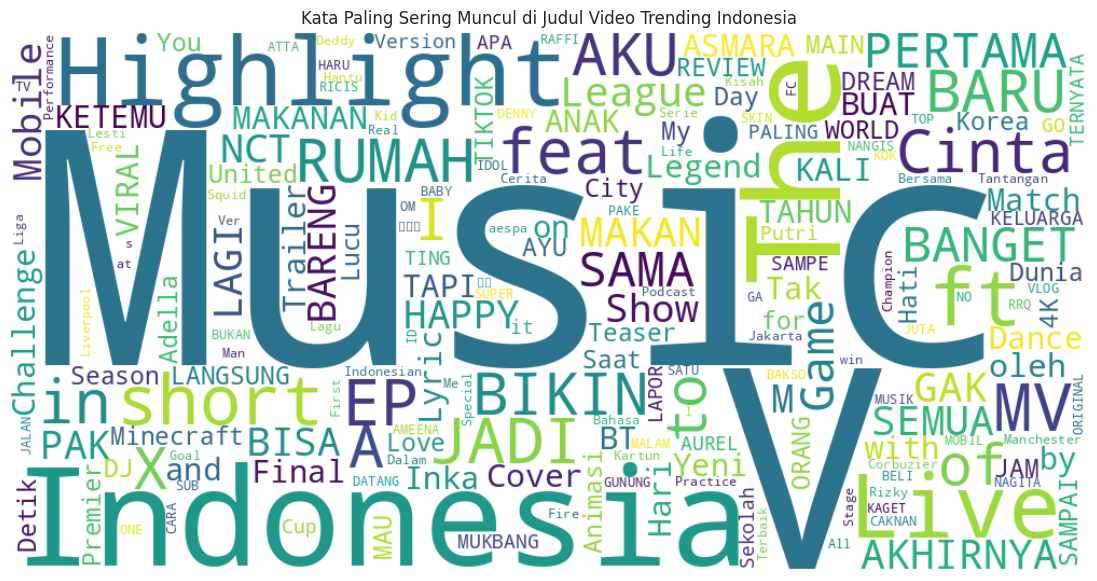

In [14]:
stopwords_id = set([
    "yang","dan","di","ke","dari","ini","itu","untuk","dengan","pada","adalah",
    "akan","atau","juga","tidak","ada","saya","kamu","kita","dia","mereka",
    "video","channel","official","full","part","episode","terbaru","new"
])

all_titles = " ".join(df['title'].astype(str).tolist())
wordcloud = WordCloud(width=1000, height=500, background_color="white",
                       stopwords=stopwords_id, collocations=False).generate(all_titles)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Kata Paling Sering Muncul di Judul Video Trending Indonesia")
plt.show()

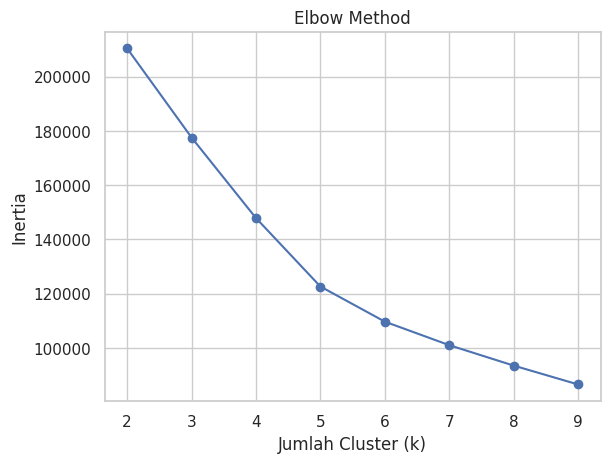

In [16]:
# 1. Pilih kolom fitur
features = ['view', 'like', 'dislike', 'comment', 'engagement_rate', 'tags_count']

# 2. Hapus baris yang mengandung NaN khusus di kolom features
df_clean = df.dropna(subset=features).copy()

# 3. Jalankan transformasi & K-Means menggunakan df_clean
X_log = np.log1p(df_clean[features])
X_scaled = StandardScaler().fit_transform(X_log)

inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [18]:
# 1. Pastikan dataframe bersih yang tidak ada NaN disimpan ke variabel baru
df_clean = df.dropna(subset=features).copy()

# 2. Proses transformasi & scaling menggunakan df_clean
X_log = np.log1p(df_clean[features])
X_scaled = StandardScaler().fit_transform(X_log)

# 3. Jalankan KMeans dan simpan ke df_clean
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Tampilkan Silhouette Score & Profiling Cluster
print("Silhouette Score:", silhouette_score(X_scaled, df_clean['cluster']))
df_clean.groupby('cluster')[features].mean()

Silhouette Score: 0.2863212118928368


,view,like,dislike,comment,engagement_rate,tags_count
cluster,,,,,,
0,1.405446e+07,832333.954125,17895.213773,88242.527203,0.105846,0.928534
1,1.908054e+06,45439.332278,1877.419845,4027.034008,0.035735,1.080683
2,2.831568e+06,106531.851327,4774.546710,4672.378953,0.056167,0.000000
3,2.669521e+05,7236.484209,182.477602,792.719767,0.039741,0.987210


In [19]:
top_cats = df['category_name'].value_counts().head(5).index
df_clf = df[df['category_name'].isin(top_cats)]

X_clf = df_clf[features]
y_clf = df_clf['category_name']
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

 Entertainment       0.72      0.77      0.74      9596
        Gaming       0.70      0.66      0.68      3285
         Music       0.74      0.78      0.76      7942
People & Blogs       0.74      0.62      0.67      4201
        Sports       0.79      0.72      0.76      2935

      accuracy                           0.73     27959
     macro avg       0.74      0.71      0.72     27959
  weighted avg       0.73      0.73      0.73     27959



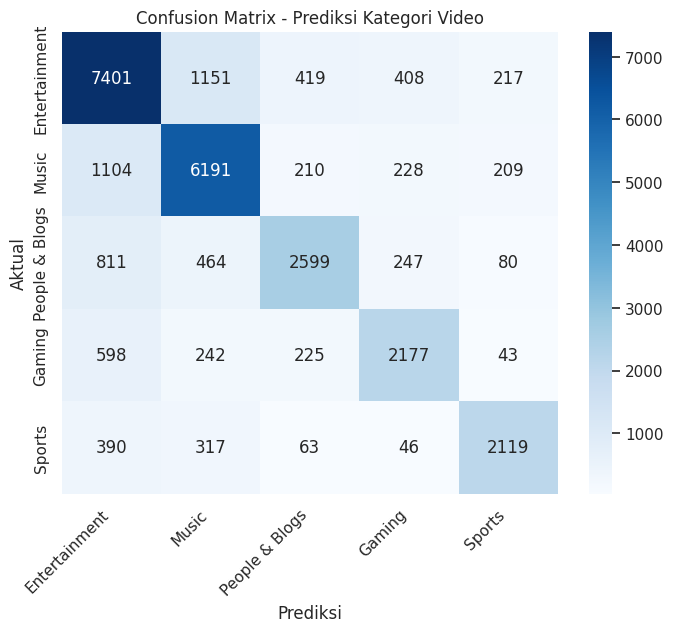

In [20]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=top_cats)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=top_cats, yticklabels=top_cats, cmap="Blues")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Prediksi Kategori Video")
plt.xticks(rotation=45, ha='right')
plt.show()